1 - Abra uma pasta do projeto
2 - Inclua a tabela anexa a pasta
3 - Crie um notebook 
(pip install das bibliotecas abaixo)
---import pandas as pd , openpyxl, matplotlib as plt,  seaborn as sns
4 - Leia a tabela
5 - Crie uma tabela de população agregada por estado
6 - Organize essa tabela por população que mais cresceu entre 2022 e 2010 (Faça a diferença se necessário)
GROUP BY
pop_estado = (
    df.groupby(["COD. UF", "UF"], as_index=False)
      .agg(
          populacao_2010=(col_2010, "sum"),
          populacao_2022=(col_2022, "sum"),
      )
)
7 - Salve essa tabela nova em csv na pasta do seu projeto
PARA SALVAR
nome_variavel.to_csv(r"caminho\nome_tabela.csv", sep =";")8 - Agora trabalhe por município
9 - Organize essa tabela por população que mais cresceu entre 2022 e 2010 (Faça a diferença se necessário)
10 - Salve essa tabela nova em csv na pasta do seu projeto
PARA SALVAR
nome_variavel.to_csv(r"caminho\nome_tabela.csv", sep =";")

11 - Faça gráficos demonstrando as populações que mais cresceram por estado.

---gerar gráfico

# Barras agrupadas: 2010 x 2022 (maiores crescimentos absolutos)
top = NOMEVARIAVELPOP POR ESTADO.head(10).melt(
    id_vars="UF",
    value_vars=["2010", "2022"],
    var_name="ano",
    value_name="populacao",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="UF", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
path = r"H:\Phyton\3 Etapa\Atividade 4\CD2022_Populacao_2010_Compatibilizada_20231222.xlsx"



In [6]:
pop_bruto = pd.read_excel(path, header=2)

In [7]:
pop_tratada = pop_bruto.iloc[0:5570, 1:].copy()

In [8]:
pop_tratada.dtypes

UF                                                      str
COD. UF                                             float64
COD. MUNIC                                          float64
NOME DO MUNICÍPIO                                       str
População Município 2010\n(Sinopse)                 float64
População 2010 (Alterações de Limites até 2022)1    float64
População Censo 2022                                float64
dtype: object

In [9]:
pop_tratada.head(50)

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0
5,RO,11.0,64.0,Colorado do Oeste,18591.0,18591.0,15663.0
6,RO,11.0,72.0,Corumbiara,8783.0,8783.0,7519.0
7,RO,11.0,80.0,Costa Marques,13678.0,13678.0,12627.0
8,RO,11.0,98.0,Espigão D'Oeste,28729.0,28729.0,29414.0
9,RO,11.0,106.0,Guajará-Mirim,41656.0,41656.0,39387.0


In [10]:
pop_tratada.columns

Index(['UF', 'COD. UF', 'COD. MUNIC', 'NOME DO MUNICÍPIO',
       'População Município 2010\n(Sinopse)',
       'População 2010 (Alterações de Limites até 2022)1',
       'População Censo 2022'],
      dtype='str')

In [11]:
pop_tratada["diferença"] = pop_tratada['População Censo 2022'] - pop_tratada['População Município 2010\n(Sinopse)']

In [12]:
pop_estado = (
    pop_tratada.groupby("UF")[["População Censo 2022", "População Município 2010\n(Sinopse)", "diferença"]]
    .sum()
    .reset_index()
)


In [13]:
pop_estado

,UF,População Censo 2022,População Município 2010\n(Sinopse),diferença
0,AC,830018.0,733559.0,96459.0
1,AL,3127683.0,3120494.0,7189.0
2,AM,3941613.0,3483985.0,457628.0
3,AP,733759.0,669526.0,64233.0
4,BA,14141626.0,14016906.0,124720.0
5,CE,8794957.0,8452381.0,342576.0
6,DF,2817381.0,2570160.0,247221.0
7,ES,3833712.0,3514952.0,318760.0
8,GO,7056495.0,6003788.0,1052707.0
9,MA,6776699.0,6574789.0,201910.0


In [14]:
pop_cidade = pop_tratada.iloc[:,3:]

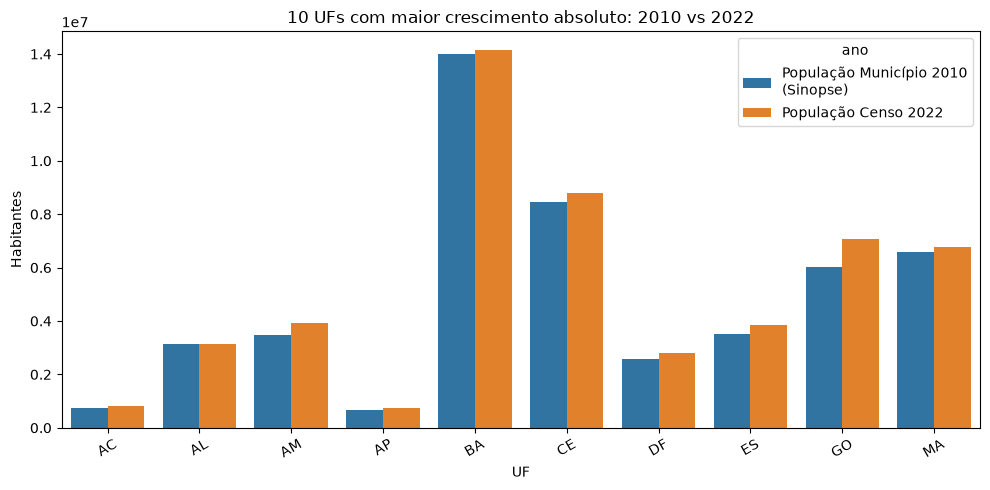

In [15]:
top = pop_estado.head(10).melt(
    id_vars="UF",
    value_vars=["População Município 2010\n(Sinopse)", "População Censo 2022"],
    var_name="ano",
    value_name="populacao",
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top, x="UF", y="populacao", hue="ano", ax=ax)
ax.set_title("10 UFs com maior crescimento absoluto: 2010 vs 2022")
ax.set_ylabel("Habitantes")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()